# Chunk Steering: Load KL Curves, Plot, and Fit
This notebook loads precomputed KL(beta) curves saved by `scripts/collect_kl_curves.py` and produces combined KL vs beta plots and amplitude-vs-metric scatterplots. It also fits an inverse model a/x + b and compares it to independent exponentials using AIC/BIC, Vuong test, and 5-fold CV.

In [5]:
import os, json, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Configure which steer file to load
model_name = 'deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B'
steer_type = 'diff-in-means'  # options: 'per-chunk' | 'centered' | 'diff-in-means'
model_tag = model_name.replace('/', '-')
repo_root = Path.cwd().resolve().parents[0] if (Path.cwd()).exists() else Path.cwd().resolve()
annotated_path = repo_root / 'data' / f'annotated_data_{model_tag}.json'
kl_path = repo_root / 'data' / f'kl_curves_steer_{steer_type}_{model_tag}.json'
print('Loading:', kl_path)
with open(annotated_path,'r') as f: annotated = json.load(f)
with open(kl_path,'r') as f: payload = json.load(f)
examples = [ex for ex in annotated if ex.get('thought_anchor_sentence')]
curves = payload.get('curves', [])
betas = np.asarray(payload.get('betas', []), dtype=float)
len(examples), len(curves), betas[:5] if betas.size > 0 else betas

Loading: /home/cutterdawes/SteeringThoughtAnchors/data/kl_curves_steer_diff-in-means_deepseek-ai-DeepSeek-R1-Distill-Qwen-1.5B.json


(20, 533, array([-10.,  -9.,  -8.,  -7.,  -6.]))

<Figure size 640x480 with 0 Axes>

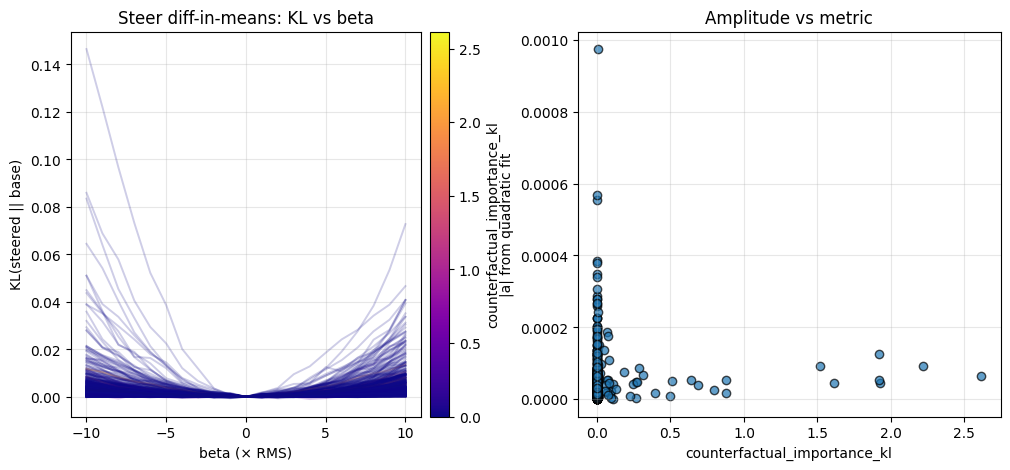

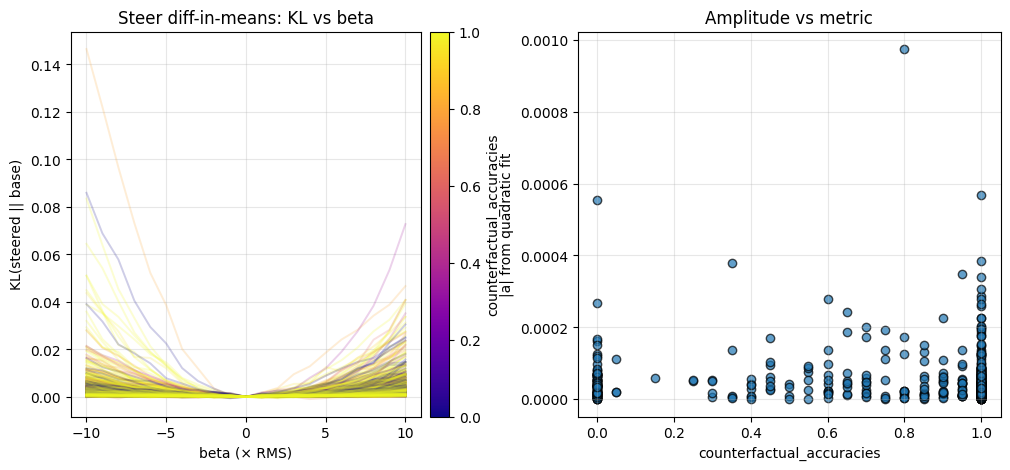

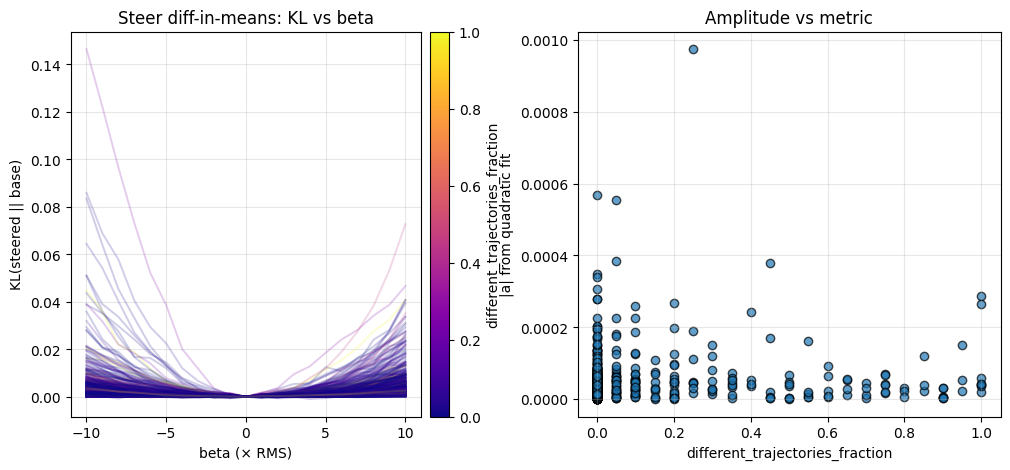

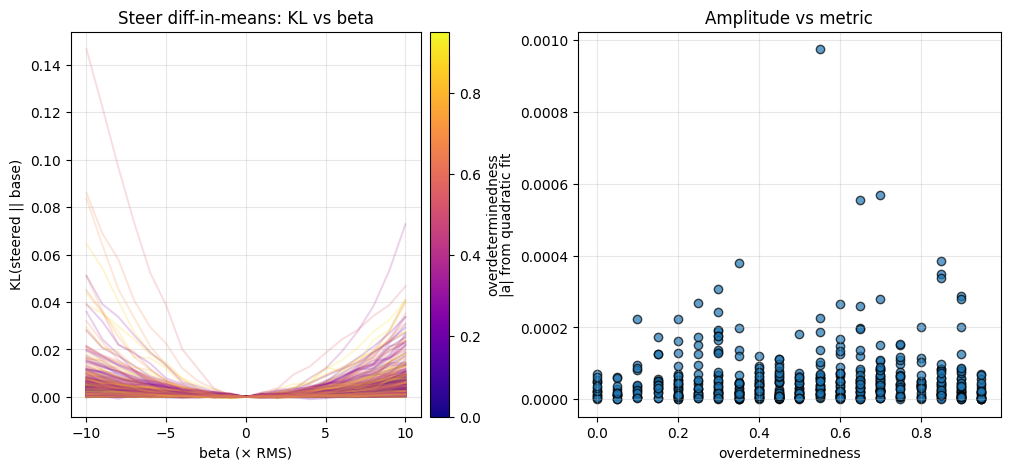

In [6]:
# Plot combined figures (KL vs beta and amplitude vs metric)
import numpy as np
from matplotlib.colors import Normalize

repo_root = Path.cwd().resolve().parents[0] if (Path.cwd()).exists() else Path.cwd().resolve()
import sys
sys.path.append(str(repo_root))

from utils import normalize_by_group

metric_key_to_label = {
    'kl': 'counterfactual_importance_kl',
    'acc': 'counterfactual_accuracies',
    'diff': 'different_trajectories_fraction',
    'over': 'overdeterminedness',
}

def _get_metric_from_example(ex, idx: int, metric_key: str) -> float:
    arr = ex.get(metric_key_to_label[metric_key], []) or []
    try: return float(arr[idx]) if idx < len(arr) else 0.0
    except Exception: return 0.0

def _fit_amp_quadratic(xs: np.ndarray, ys: np.ndarray) -> float:
    n = min(xs.size, ys.size)
    if n < 3: return np.nan
    try: return abs(float(np.polyfit(xs[:n], ys[:n], 2)[0]))
    except Exception: return np.nan

def plot_combined_for_chunk_list(curves: list, examples_list: list, x_values: np.ndarray, metric_key: str, title_prefix: str, save: bool = False, normalize_amp: bool = True):
    vals, amps, ex_keys = [], [], []
    for c in curves:
        ex_i = int(c.get('example_index', 0)); ch_i = int(c.get('chunk_index', 0))
        vals.append(_get_metric_from_example(examples_list[ex_i], ch_i, metric_key))
        ex_keys.append(ex_i)
        ys = np.asarray(c.get('ys', []) or [], dtype=float)
        amps.append(_fit_amp_quadratic(np.asarray(x_values, dtype=float), ys))
    M = np.asarray(vals, dtype=float); A = np.asarray(amps, dtype=float)
    A_plot = np.asarray(normalize_by_group(ex_keys, A), dtype=float) if normalize_amp else A
    vmin, vmax = (0.0, (np.nanmax(M) if np.isfinite(np.nanmax(M)) else 1.0)) if metric_key != 'kl' else (0.0, (np.nanmax(M) if np.isfinite(np.nanmax(M)) else 0.01))
    norm = Normalize(vmin=vmin, vmax=max(vmin+1e-9, vmax)); cmap = plt.cm.plasma
    fig, axes = plt.subplots(1,2, figsize=(12,5)); ax0, ax1 = axes
    for c, m in zip(curves, M):
        ys = np.asarray(c.get('ys', []) or [], dtype=float)
        n = min(len(x_values), len(ys))
        if n == 0: continue
        ax0.plot(x_values[:n], ys[:n], color=cmap(norm(m)), linewidth=1.4, alpha=0.2)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array(M)
    cb = fig.colorbar(sm, ax=ax0, pad=0.02); cb.set_label(metric_key_to_label[metric_key])
    ax0.set_xlabel('beta (× RMS)'); ax0.set_ylabel('KL(steered || base)'); ax0.set_title(f'{title_prefix}: KL vs beta')
    ax0.grid(True, alpha=0.3)
    ax1.scatter(M, A_plot, edgecolor='black', alpha=0.7)
    ax1.set_xlabel(metric_key_to_label[metric_key]); ax1.set_ylabel(('normalized |a| (per example)' if normalize_amp else '|a| from quadratic fit'))
    ax1.set_title('Amplitude vs metric'); ax1.grid(True, alpha=0.3)
    
    
    # Optional save to data/figures when save=True
    if save:
        from pathlib import Path as _P
        _rr = _P.cwd().resolve().parents[0] if (_P.cwd()).exists() else _P.cwd().resolve()
        save_dir = _rr / 'data' / 'figures'
        try: save_dir.mkdir(parents=True, exist_ok=True)
        except Exception: pass
        base = f"steer_{steer_type}_{model_tag}"
        fname = f"{base}_{metric_key}.png"
        try: fig.savefig(save_dir / fname, dpi=200, bbox_inches='tight')
        except Exception: pass
plt.tight_layout(); plt.show()

metrics = ['kl','acc','diff','over']
for mk in metrics:
    plot_combined_for_chunk_list(curves, examples, betas, mk, f'Steer {steer_type}', save=True, normalize_amp=False)

In [12]:
# Fit scatter with Frank copula (exponential marginals)
import numpy as np
from dataclasses import dataclass
from scipy.optimize import minimize
from scipy.integrate import quad

# Extract metric (X) and amplitude (Y) pairs

def _MA_from_curves(curves, examples, x_values, metric_key):
    vals = []; amps = []
    for c in curves:
        ex_i = int(c.get('example_index', 0)); ch_i = int(c.get('chunk_index', 0))
        arr = examples[ex_i].get({'kl':'counterfactual_importance_kl','acc':'counterfactual_accuracies','diff':'different_trajectories_fraction','over':'overdeterminedness'}[metric_key], []) or []
        v = float(arr[ch_i]) if ch_i < len(arr) else 0.0
        ys = np.asarray(c.get('ys', []) or [], dtype=float)
        n = min(len(x_values), len(ys))
        if n < 3: continue
        try:
            acoef = float(np.polyfit(x_values[:n], ys[:n], 2)[0])
        except Exception:
            continue
        vals.append(max(0.0, v)); amps.append(abs(acoef))
    X = np.asarray(vals, dtype=float)
    Y = np.asarray(amps, dtype=float)
    m = np.isfinite(X) & np.isfinite(Y) & (X >= 0) & (Y >= 0)
    return X[m], Y[m]

# Exponential marginals: lambda = 1/mean

def estimate_marginals(x, y):
    lam_x = 1.0 / max(np.mean(x), 1e-12)
    lam_y = 1.0 / max(np.mean(y), 1e-12)
    return lam_x, lam_y

# Frank copula log-density (numerically stable)

def frank_log_copula_density(u, v, theta):
    """Return elementwise log copula density for Frank copula.

    This implementation avoids overflow/invalid logs by:
      - clipping theta magnitude to a safe range for exponentials
      - using expm1-based differences where helpful
      - clamping denominators to a small positive value
      - mapping non-finite results to a very negative log-density
    """
    u = np.clip(u, 1e-12, 1 - 1e-12)
    v = np.clip(v, 1e-12, 1 - 1e-12)
    # small-theta limit
    if abs(theta) < 1e-8:
        return np.zeros_like(u)

    # Prevent overflow in np.exp by capping exponent arguments and theta magnitude
    max_exp = 700.0
    theta_safe = np.sign(theta) * min(abs(theta), max_exp)

    tu = -theta_safe * u
    tv = -theta_safe * v
    t = -theta_safe

    # Use expm1 for (exp(x)-1) when possible
    Am1 = np.expm1(np.clip(tu, -max_exp, max_exp))  # exp(tu) - 1
    Bm1 = np.expm1(np.clip(tv, -max_exp, max_exp))  # exp(tv) - 1
    # E = exp(-theta)
    E = np.exp(np.clip(t, -max_exp, max_exp))

    # denom term = (exp(tu)-1)*(exp(tv)-1) + (1 - E)
    denom = Am1 * Bm1 + (1.0 - E)
    # clamp to positive
    denom = np.where(denom <= 0.0, 1e-300, denom)

    # compute log of numerator magnitude robustly
    one_minus_E = 1.0 - E
    log_num_abs = np.log(np.abs(theta_safe)) - theta_safe*(u+v) + np.log(np.abs(one_minus_E))

    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        log_den = 2.0 * np.log(denom)
        val = log_num_abs - log_den

    # Replace non-finite results with a large negative number (log-density ~= -inf)
    val = np.where(np.isfinite(val), val, -1e300)
    return val

@dataclass
class FitReport:
    n: int
    lam_x: float
    lam_y: float
    theta: float
    ll_indep: float
    ll_total: float
    aic: float
    bic: float
    tau: float


# Local Debye(1) implementation: D1(theta) = (1/theta) * integral_0^theta t/(e^t - 1) dt
# SciPy in some environments may not provide scipy.special.debye; implement robust numeric fallback.

def debye1(theta):
    """Compute Debye function of order 1 (D1) for scalar or array-like theta.

    Uses numerical integration (scipy.integrate.quad) per scalar. For theta->0 uses the known limit D1(0)=1 and a short series.
    """
    import numpy as _np

    def _D1_scalar(t):
        t = float(t)
        if abs(t) < 1e-12:
            # series expansion around 0: D1(t) = 1 - t/4 + t^2/36 - ...
            return 1.0 - t/4.0 + (t**2)/36.0
        integrand = lambda x: x/(_np.exp(x) - 1.0)
        val, _ = quad(integrand, 0.0, t, epsabs=1e-8, epsrel=1e-8, limit=200)
        return val / t

    theta_arr = np.atleast_1d(theta)
    res = np.array([_D1_scalar(t) for t in theta_arr])
    if np.isscalar(theta):
        return float(res[0])
    return res


def fit_frank_copula_expon(x, y):
    # Estimate marginals
    lam_x, lam_y = estimate_marginals(x, y)
    # Transform to uniforms
    u = 1.0 - np.exp(-lam_x * x)
    v = 1.0 - np.exp(-lam_y * y)
    u = np.clip(u, 1e-12, 1 - 1e-12)
    v = np.clip(v, 1e-12, 1 - 1e-12)

    # Marginal log-likelihoods (exponential)
    ll_marg = np.sum(np.log(lam_x) - lam_x*x) + np.sum(np.log(lam_y) - lam_y*y)

    # Optimize theta by maximizing copula log-likelihood
    def nll(th):
        th = float(th[0])
        llc = np.sum(frank_log_copula_density(u, v, th))
        return -llc

    # Use bounded optimizer to avoid exploring extreme theta values that cause overflow
    theta_bound = 100.0
    res = minimize(nll, x0=np.array([0.5]), method='L-BFGS-B', bounds=[(-theta_bound, theta_bound)])

    if not res.success:
        # fallback: try a safer initial value or return independence
        # don't crash — return independence fit
        theta = 0.0
    else:
        theta = float(res.x[0])
        # clip to safe range in case optimizer returns boundary values
        theta = float(np.clip(theta, -theta_bound, theta_bound))

    # Compute totals
    ll_cop = np.sum(frank_log_copula_density(u, v, theta))
    ll_total = float(ll_marg + ll_cop)
    # Independence (theta=0) => copula ll = 0
    ll_indep = float(ll_marg)
    n = len(x)
    k = 3  # lam_x, lam_y, theta
    aic = 2*k - 2*ll_total
    bic = k*np.log(max(n,1)) - 2*ll_total
    # Kendall's tau for Frank: tau = 1 + 4/theta * (D1(theta) - 1)
    if abs(theta) < 1e-8:
        tau = 0.0
    else:
        # compute Debye safely and guard against non-finite values
        D1 = debye1(theta)
        if not np.isfinite(D1):
            tau = 0.0
        else:
            tau = 1.0 + (4.0/theta) * (D1 - 1.0)
    return FitReport(n=n, lam_x=lam_x, lam_y=lam_y, theta=theta, ll_indep=ll_indep, ll_total=ll_total, aic=aic, bic=bic, tau=float(tau))

metrics = ['kl','acc','diff','over']
for mk in metrics:
    x, y = _MA_from_curves(curves, examples, betas if 'betas' in globals() else epsilons, mk)
    if len(x) < 8:
        print(f'[copula] {mk}: not enough points');
        continue
    rep = fit_frank_copula_expon(x, y)
    print(f"[copula] {mk}: n={rep.n} lam_x={rep.lam_x:.4g} lam_y={rep.lam_y:.4g} theta={rep.theta:.4g} | ll(indep)={rep.ll_indep:.3f} ll(fit)={rep.ll_total:.3f} AIC={rep.aic:.1f} BIC={rep.bic:.1f} tau={rep.tau:.3f}")


[copula] kl: n=533 lam_x=23.6 lam_y=1.258e+04 theta=-100 | ll(indep)=5650.310 ll(fit)=750081.910 AIC=-1500157.8 BIC=-1500145.0 tau=-0.961
[copula] acc: n=533 lam_x=1.326 lam_y=1.258e+04 theta=-100 | ll(indep)=4115.770 ll(fit)=432151.761 AIC=-864297.5 BIC=-864284.7 tau=-0.961
[copula] diff: n=533 lam_x=8.562 lam_y=1.258e+04 theta=-100 | ll(indep)=5109.906 ll(fit)=604944.056 AIC=-1209882.1 BIC=-1209869.3 tau=-0.961
[copula] over: n=533 lam_x=1.936 lam_y=1.258e+04 theta=-100 | ll(indep)=4317.396 ll(fit)=425362.795 AIC=-850719.6 BIC=-850706.8 tau=-0.961


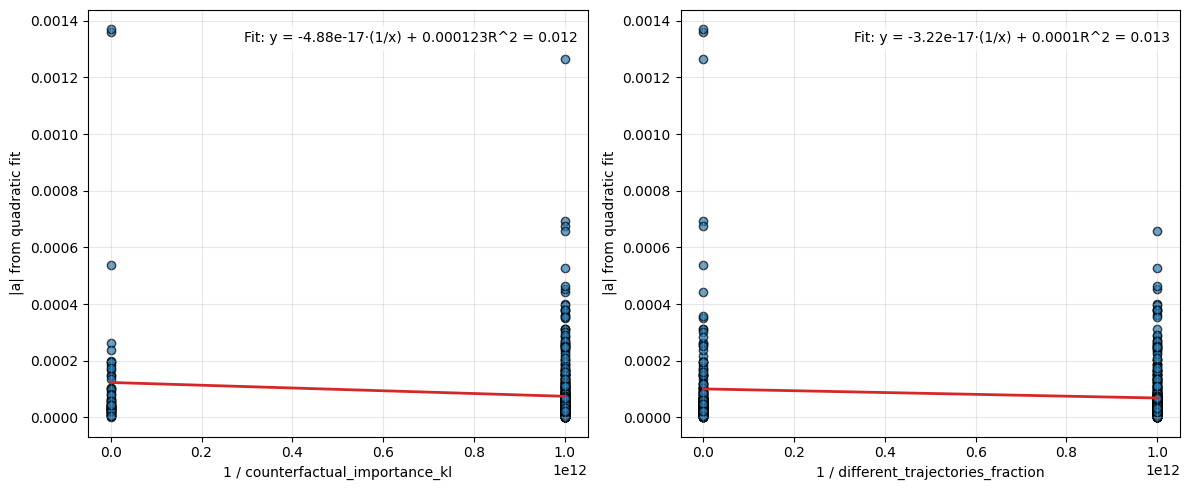

In [13]:
# Scatter with 1/x on X and linear fit (y = a x + b) for kl and diff
import numpy as np
import matplotlib.pyplot as plt

metrics_plot = ['kl', 'diff']
fig, axes = plt.subplots(1, len(metrics_plot), figsize=(12,5))
if len(metrics_plot)==1:
    axes=[axes]
for ax, mk in zip(axes, metrics_plot):
    x, y = _MA_from_curves(curves, examples, betas if 'betas' in globals() else epsilons, mk)
    if len(x) < 3:
        ax.set_title(f'{mk}: not enough points'); ax.axis('off'); continue
    invx = 1.0 / np.clip(x, 1e-12, None)
    ax.scatter(invx, y, edgecolor='black', alpha=0.7)
    ax.set_xlabel('1 / ' + {'kl':'counterfactual_importance_kl','diff':'different_trajectories_fraction'}[mk])
    ax.set_ylabel('|a| from quadratic fit')
    # Linear least squares
    X = np.vstack([invx, np.ones_like(invx)]).T
    a,b = np.linalg.lstsq(X, y, rcond=None)[0]
    xs = np.linspace(float(invx.min()), float(invx.max()), 200)
    ys_fit = a*xs + b
    ax.plot(xs, ys_fit, color='tab:red', linewidth=2.0)
    # R^2
    yhat = a*invx + b
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1.0 - (ss_res/ss_tot if ss_tot > 1e-12 else 0.0)
    ax.text(0.98, 0.95, f'Fit: y = {a:.3g}·(1/x) + {b:.3g}R^2 = {r2:.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()